In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from joblib import dump

---
## Preprocessing

In [60]:
df = pd.read_csv('data/Telco-Customer-Churn.csv')

In [61]:
df.set_index('customerID', inplace=True)

In [62]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No': 0, 'Yes': 1})

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [65]:
cat_cols = X.select_dtypes(include='object').columns

In [66]:
num_cols = X.select_dtypes(exclude='object').columns

In [67]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

In [68]:
scaler = StandardScaler()

---
## Training Model

In [69]:
models = {
    'logistic_regression': LogisticRegression(solver='saga', max_iter=5000, class_weight='balanced'),
    'svc': SVC(max_iter=5000, class_weight='balanced'),
    'random_forest': RandomForestClassifier(class_weight='balanced'),
    'adaboost': AdaBoostClassifier(),
    'gradient_boosting': GradientBoostingClassifier(),
}

In [70]:
param_grid = {
    'logistic_regression': {
        'logistic_regression__penalty': ['l1', 'l2', 'elasticnet'],
        'logistic_regression__l1_ratio': [0.1, 0.5, 0.8, 1.0],
        'logistic_regression__C': np.logspace(-3, 3, 3),
    },
    'svc': {
        'svc__C': np.logspace(-3, 3, 3),
        'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'svc__gamma': [0.01, 0.1, 1.0],
        'svc__degree': [1, 2, 3, 4],
    },
    'random_forest': {
        'random_forest__n_estimators': [50, 100, 150],
        'random_forest__max_features': ['sqrt', 'log2'],
        'random_forest__criterion': ['gini', 'entropy'],
        'random_forest__min_samples_split': [2, 5, 10],
    },
    'adaboost': {
        'adaboost__n_estimators': [50, 100, 150],
        'adaboost__learning_rate': [0.1, 0.5, 0.8, 1.0],
    },
    'gradient_boosting': {
        'gradient_boosting__n_estimators': [50, 100, 150],
        'gradient_boosting__learning_rate': [0.1, 0.5, 0.8, 1.0],
    },
}

In [71]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

In [1]:
best_models = {}
cv_results = []

for name, model in models.items():
    if name in ['logistic_regression', 'svc']:
        pipe = Pipeline(steps=[('preprocessor', preprocessor), ('scaler', scaler), (name, model)])
    else:
        pipe = Pipeline(steps=[('preprocessor', preprocessor), (name, model)])
    
    grid_model = GridSearchCV(pipe, param_grid.get(name), cv=cv, scoring='f1_weighted') 
    grid_model.fit(X_train, y_train)
    
    best_models[name] = grid_model.best_estimator_
    
    cv_results.append(
        {
            'model': name,
            'f1_weighted': grid_model.best_score_,
            'best_params': grid_model.best_params_,
        }
    )

NameError: name 'models' is not defined

In [84]:
pd.Series(best_models)

logistic_regression    (ColumnTransformer(transformers=[('cat', OneHo...
svc                    (ColumnTransformer(transformers=[('cat', OneHo...
random_forest          (ColumnTransformer(transformers=[('cat', OneHo...
adaboost               (ColumnTransformer(transformers=[('cat', OneHo...
gradient_boosting      (ColumnTransformer(transformers=[('cat', OneHo...
dtype: object

In [138]:
cv_result_df = pd.DataFrame(cv_results)

In [139]:
cv_result_df

,model,f1_weighted,best_params
0,logistic_regression,0.762170,"{'logistic_regression__C': 1.0, 'logistic_regr..."
1,svc,0.758729,"{'svc__C': 1.0, 'svc__degree': 1, 'svc__gamma'..."
2,random_forest,0.785918,"{'random_forest__criterion': 'gini', 'random_f..."
3,adaboost,0.793285,"{'adaboost__learning_rate': 0.8, 'adaboost__n_..."
4,gradient_boosting,0.792214,"{'gradient_boosting__learning_rate': 0.1, 'gra..."


In [164]:
test_result = dict()

for name, est in best_models.items():
    predict = est.predict(X_test)
    f1 = f1_score(y_test, predict, average='weighted')
    test_result[name] = f1
    
    conf_matrix = confusion_matrix(y_test, predict)
    print(f"Confusion Matrix for {name}: \n{conf_matrix}")
    print(classification_report(y_test, predict))
    

Confusion Matrix for logistic_regression: 
[[402 155]
 [ 36 111]]
              precision    recall  f1-score   support

           0       0.92      0.72      0.81       557
           1       0.42      0.76      0.54       147

    accuracy                           0.73       704
   macro avg       0.67      0.74      0.67       704
weighted avg       0.81      0.73      0.75       704

Confusion Matrix for svc: 
[[433 124]
 [ 51  96]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       557
           1       0.44      0.65      0.52       147

    accuracy                           0.75       704
   macro avg       0.67      0.72      0.68       704
weighted avg       0.80      0.75      0.77       704

Confusion Matrix for random_forest: 
[[472  85]
 [ 61  86]]
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       557
           1       0.50      0.59      0.54       147

    ac

In [141]:
test_result

{'logistic_regression': 0.7515558822618487,
 'svc': 0.7674271380103875,
 'random_forest': 0.7981563842510269,
 'adaboost': 0.8154223766502803,
 'gradient_boosting': 0.8136985153423931}

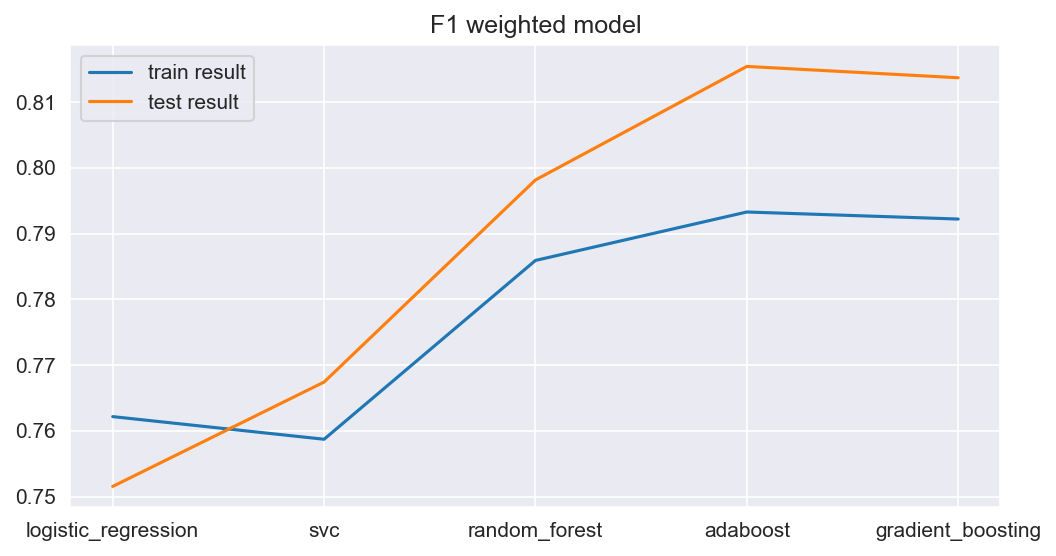

In [142]:
plt.figure(figsize=(8, 4), dpi=150)

plt.plot(cv_result_df['model'], cv_result_df['f1_weighted'], label='train result')
plt.plot(test_result.keys(), test_result.values(), label='test result',)

plt.legend()
plt.title('F1 weighted model');

---
## Training Final Model

In [173]:
cv_result_df[cv_result_df['model'] == 'logistic_regression']['best_params']

0    {'logistic_regression__C': 1.0, 'logistic_regr...
Name: best_params, dtype: object

In [178]:
final_model = LogisticRegression(solver='saga', max_iter=5000, class_weight='balanced', C=1.0, penalty='l2')

In [179]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', scaler),
    ('logistic_regression', final_model),
])

In [183]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))])),
                ('scaler', StandardScaler()),
                ('logistic_regression',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    solver='saga'))])

In [185]:
dump(pipeline, 'model/final_model.pkl')

['model/final_model.pkl']